# Module 1: Understanding the Data - Exploratory Data Analysis

This notebook covers comprehensive exploration of e-commerce sales data.

## Learning Objectives
- Load and inspect e-commerce sales data
- Identify time series characteristics
- Detect missing dates, zero sales, and data quality issues
- Visualize seasonality, trends, and product life cycles
- Profile data at SKU and category levels


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import project utilities
import sys
sys.path.append('../')
from src.data.loaders import load_sales_data, load_sample_data, validate_data

print("Libraries imported successfully!")


Libraries imported successfully!


## Part 1: Data Loading and Initial Inspection

First, let's load the data and get a high-level understanding.


In [4]:
# Load data
# Try loading from different possible paths (notebook might be run from different directories)
sample_paths = [
    '../data/raw/sample_sales.csv',  # From notebooks/ directory (most common)
    'data/raw/sample_sales.csv',      # From project root
]

df = None
loaded_path = None

for path_str in sample_paths:
    path = Path(path_str)
    if path.exists():
        try:
            df = load_sales_data(path)
            loaded_path = path_str
            print(f"✓ Loaded sample data from: {path_str}")
            break
        except Exception as e:
            print(f"⚠ Could not load from {path_str}: {e}")
            continue

# If not found, provide helpful error message
if df is None:
    print("\n❌ Sample data not found in expected locations.")
    print("Expected locations:")
    for p in sample_paths:
        print(f"  - {p}")
    print("\nTo generate sample data, run:")
    print("  python scripts/generate_sample_data.py --output data/raw/sample_sales.csv --days 730 --skus 100")
    print("\nOr load your own data:")
    print("  df = load_sales_data('data/raw/your_data.csv')")
    raise FileNotFoundError("Could not find sample data. Please generate it or provide your own data file.")

# Display basic info
print(f"\nData shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst few rows:")
df.head()


✓ Loaded sample data from: ../data/raw/sample_sales.csv

Data shape: (365000, 9)

Column names: ['date', 'sku_id', 'category', 'subcategory', 'price', 'units_sold', 'revenue', 'promotion_flag', 'stock_available']

Data types:
date               datetime64[ns]
sku_id                     object
category                   object
subcategory                object
price                     float64
units_sold                  int64
revenue                   float64
promotion_flag               bool
stock_available             int64
dtype: object

First few rows:


,date,sku_id,category,subcategory,price,units_sold,revenue,promotion_flag,stock_available
0,2023-12-17,SKU001,Electronics,Accessories,155.30,23,3571.80,False,8
1,2023-12-17,SKU002,Electronics,Audio,123.64,0,0.00,False,116
2,2023-12-17,SKU003,Electronics,Accessories,27.98,30,839.38,False,63
3,2023-12-17,SKU004,Electronics,Phones,130.11,120,15612.98,False,10
4,2023-12-17,SKU005,Electronics,Laptops,19.76,85,1679.97,False,87


In [5]:
# Basic statistics
print("Summary Statistics:")
print(df.describe())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nData Info:")
df.info()


Summary Statistics:
                                date          price     units_sold  \
count                         365000  365000.000000  365000.000000   
mean   2024-12-15 11:59:59.999999488     106.871106      32.269877   
min              2023-12-17 00:00:00       7.080000       0.000000   
25%              2024-06-16 00:00:00      60.400000      12.000000   
50%              2024-12-15 12:00:00     108.950000      28.000000   
75%              2025-06-16 00:00:00     152.970000      47.000000   
max              2025-12-15 00:00:00     209.850000     302.000000   
std                              NaN      54.423504      26.790534   

             revenue  stock_available  
count  365000.000000    365000.000000  
mean     3465.817481        99.607803  
min         0.000000         0.000000  
25%       742.347500        49.000000  
50%      2359.505000       100.000000  
75%      5115.832500       150.000000  
max     46869.850000       199.000000  
std      3643.771870        5

## Part 2: Time Series Characteristics

Understanding temporal patterns in the data.


In [6]:
# Date range analysis
print("Date Range Analysis:")
print(f"Start date: {df['date'].min()}")
print(f"End date: {df['date'].max()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days}")
print(f"Unique dates: {df['date'].nunique()}")

# Check for missing dates
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = set(all_dates) - set(df['date'].unique())
print(f"\nMissing dates: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"First 10 missing dates: {sorted(list(missing_dates))[:10]}")


Date Range Analysis:
Start date: 2023-12-17 00:00:00
End date: 2025-12-15 00:00:00
Total days: 729
Unique dates: 730

Missing dates: 0


In [7]:
# SKU-level date range analysis
sku_date_ranges = df.groupby('sku_id')['date'].agg(['min', 'max', 'count'])
sku_date_ranges['days_span'] = (sku_date_ranges['max'] - sku_date_ranges['min']).dt.days
sku_date_ranges['coverage'] = sku_date_ranges['count'] / (sku_date_ranges['days_span'] + 1)

print("SKU Date Range Statistics:")
print(sku_date_ranges.describe())

print("\nSKUs with shortest history:")
print(sku_date_ranges.nsmallest(10, 'days_span'))

print("\nSKUs with longest history:")
print(sku_date_ranges.nlargest(10, 'days_span'))


SKU Date Range Statistics:
                       min                  max  count  days_span  coverage
count                  500                  500  500.0      500.0     500.0
mean   2023-12-17 00:00:00  2025-12-15 00:00:00  730.0      729.0       1.0
min    2023-12-17 00:00:00  2025-12-15 00:00:00  730.0      729.0       1.0
25%    2023-12-17 00:00:00  2025-12-15 00:00:00  730.0      729.0       1.0
50%    2023-12-17 00:00:00  2025-12-15 00:00:00  730.0      729.0       1.0
75%    2023-12-17 00:00:00  2025-12-15 00:00:00  730.0      729.0       1.0
max    2023-12-17 00:00:00  2025-12-15 00:00:00  730.0      729.0       1.0
std                    NaN                  NaN    0.0        0.0       0.0

SKUs with shortest history:
              min        max  count  days_span  coverage
sku_id                                                  
SKU001 2023-12-17 2025-12-15    730        729       1.0
SKU002 2023-12-17 2025-12-15    730        729       1.0
SKU003 2023-12-17 2025-12-15    

## Part 3: Sales Distribution Analysis

Understanding sales volume patterns.


Zero sales records: 54802 (15.01%)
Non-zero sales records: 310198 (84.99%)


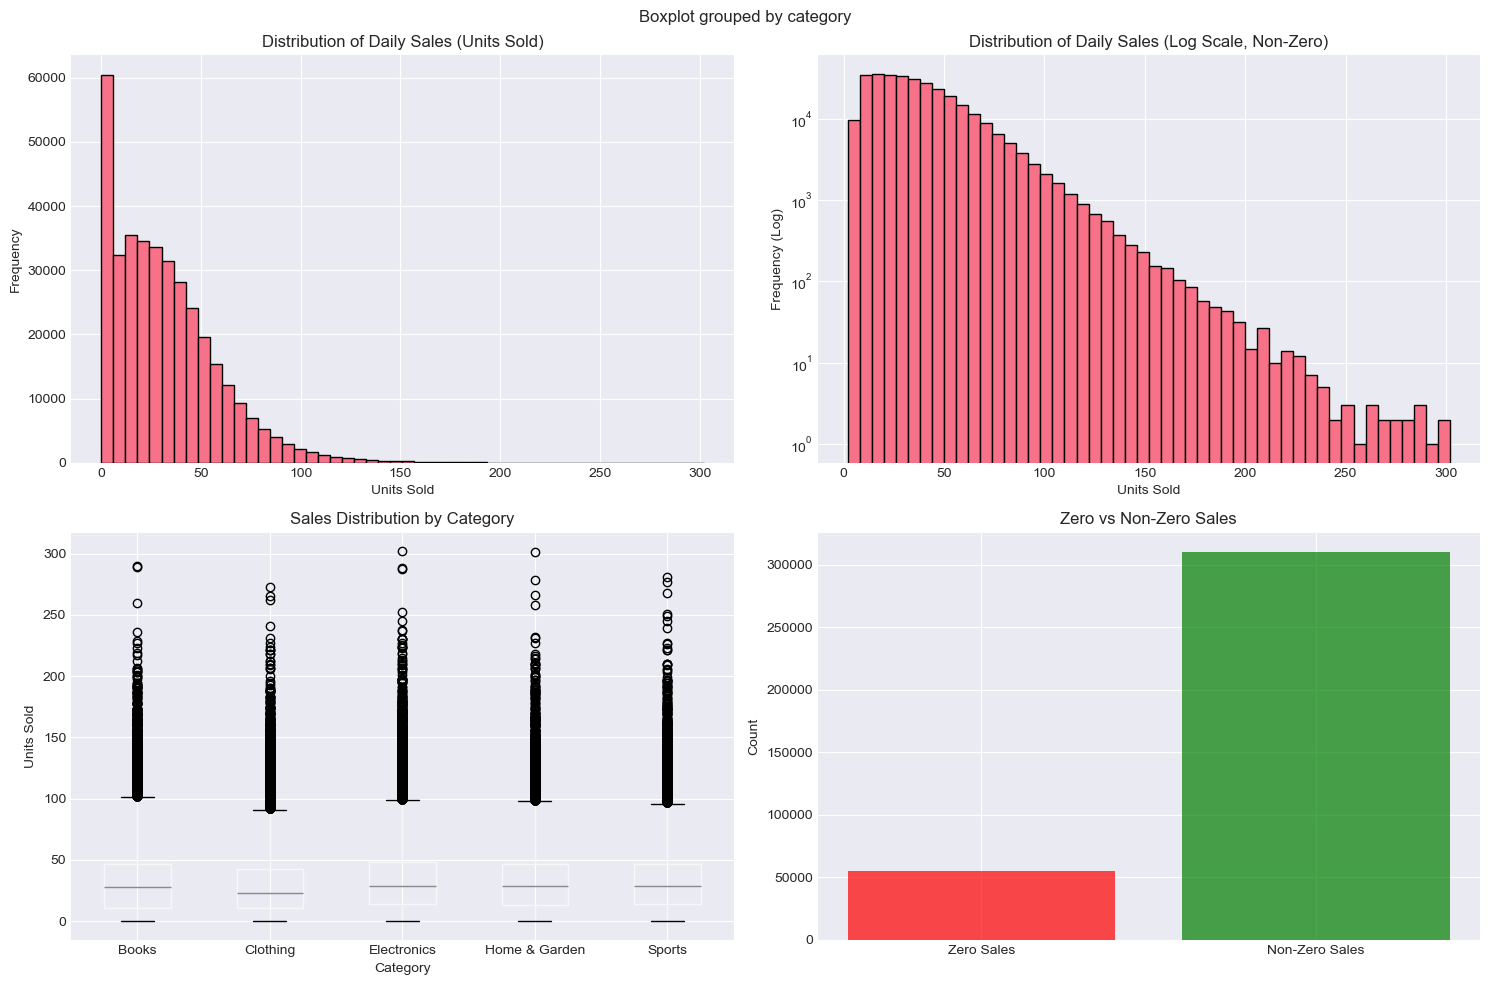

In [8]:
# Sales distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of daily sales
axes[0, 0].hist(df['units_sold'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Daily Sales (Units Sold)')
axes[0, 0].set_xlabel('Units Sold')
axes[0, 0].set_ylabel('Frequency')

# Log scale for better visualization
axes[0, 1].hist(df[df['units_sold'] > 0]['units_sold'], bins=50, edgecolor='black')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution of Daily Sales (Log Scale, Non-Zero)')
axes[0, 1].set_xlabel('Units Sold')
axes[0, 1].set_ylabel('Frequency (Log)')

# Box plot by category
if 'category' in df.columns:
    df.boxplot(column='units_sold', by='category', ax=axes[1, 0])
    axes[1, 0].set_title('Sales Distribution by Category')
    axes[1, 0].set_xlabel('Category')
    axes[1, 0].set_ylabel('Units Sold')

# Zero sales analysis
zero_sales = (df['units_sold'] == 0).sum()
total_records = len(df)
print(f"Zero sales records: {zero_sales} ({zero_sales/total_records*100:.2f}%)")
print(f"Non-zero sales records: {total_records - zero_sales} ({(total_records-zero_sales)/total_records*100:.2f}%)")

axes[1, 1].bar(['Zero Sales', 'Non-Zero Sales'], 
               [zero_sales, total_records - zero_sales],
               color=['red', 'green'], alpha=0.7)
axes[1, 1].set_title('Zero vs Non-Zero Sales')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/visualizations/sales_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


Top 10 SKUs by Total Units Sold:
        units_sold     revenue  days_with_sales
sku_id                                         
SKU484       47085  2824705.49              730
SKU435       46005  8028484.36              730
SKU442       44806  8115454.23              730
SKU397       44577   451380.81              730
SKU075       44138  1840111.35              730
SKU014       44095  8147629.76              730
SKU422       44012  6937586.53              730
SKU186       43971  5201065.93              730
SKU059       43762  2558705.67              730
SKU065       43636  4194200.84              730

Bottom 10 SKUs by Total Units Sold:
        units_sold    revenue  days_with_sales
sku_id                                        
SKU464        5587  959040.76              730
SKU113        5494  954825.37              730
SKU350        5394  460452.25              730
SKU420        5194  884962.84              730
SKU318        5182  635315.94              730
SKU098        5077  39520

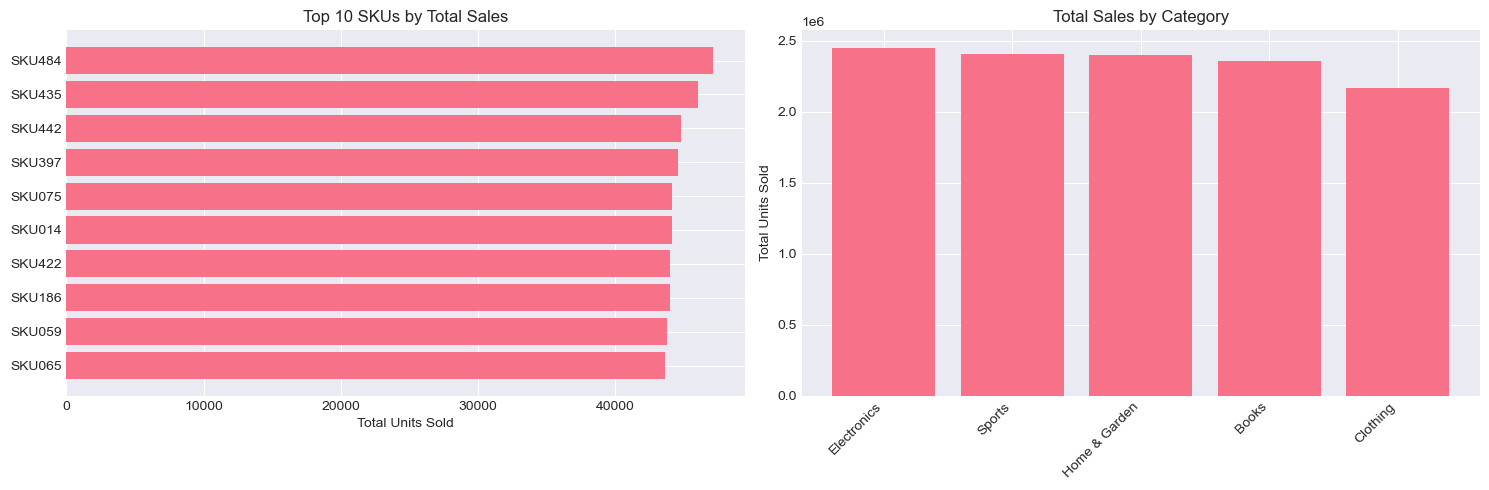

In [9]:
# Top and bottom performing SKUs
sku_performance = df.groupby('sku_id').agg({
    'units_sold': 'sum',
    'revenue': 'sum',
    'date': 'count'
}).rename(columns={'date': 'days_with_sales'})

sku_performance = sku_performance.sort_values('units_sold', ascending=False)

print("Top 10 SKUs by Total Units Sold:")
print(sku_performance.head(10))

print("\nBottom 10 SKUs by Total Units Sold:")
print(sku_performance.tail(10))

# Visualize top SKUs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_10 = sku_performance.head(10)
axes[0].barh(range(len(top_10)), top_10['units_sold'])
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(top_10.index)
axes[0].set_xlabel('Total Units Sold')
axes[0].set_title('Top 10 SKUs by Total Sales')
axes[0].invert_yaxis()

# Category-level analysis
if 'category' in df.columns:
    category_sales = df.groupby('category')['units_sold'].sum().sort_values(ascending=False)
    axes[1].bar(range(len(category_sales)), category_sales.values)
    axes[1].set_xticks(range(len(category_sales)))
    axes[1].set_xticklabels(category_sales.index, rotation=45, ha='right')
    axes[1].set_ylabel('Total Units Sold')
    axes[1].set_title('Total Sales by Category')

plt.tight_layout()
plt.savefig('../outputs/visualizations/sku_performance.png', dpi=300, bbox_inches='tight')
plt.show()


## Part 4: Seasonality Detection

Identifying seasonal patterns in sales.


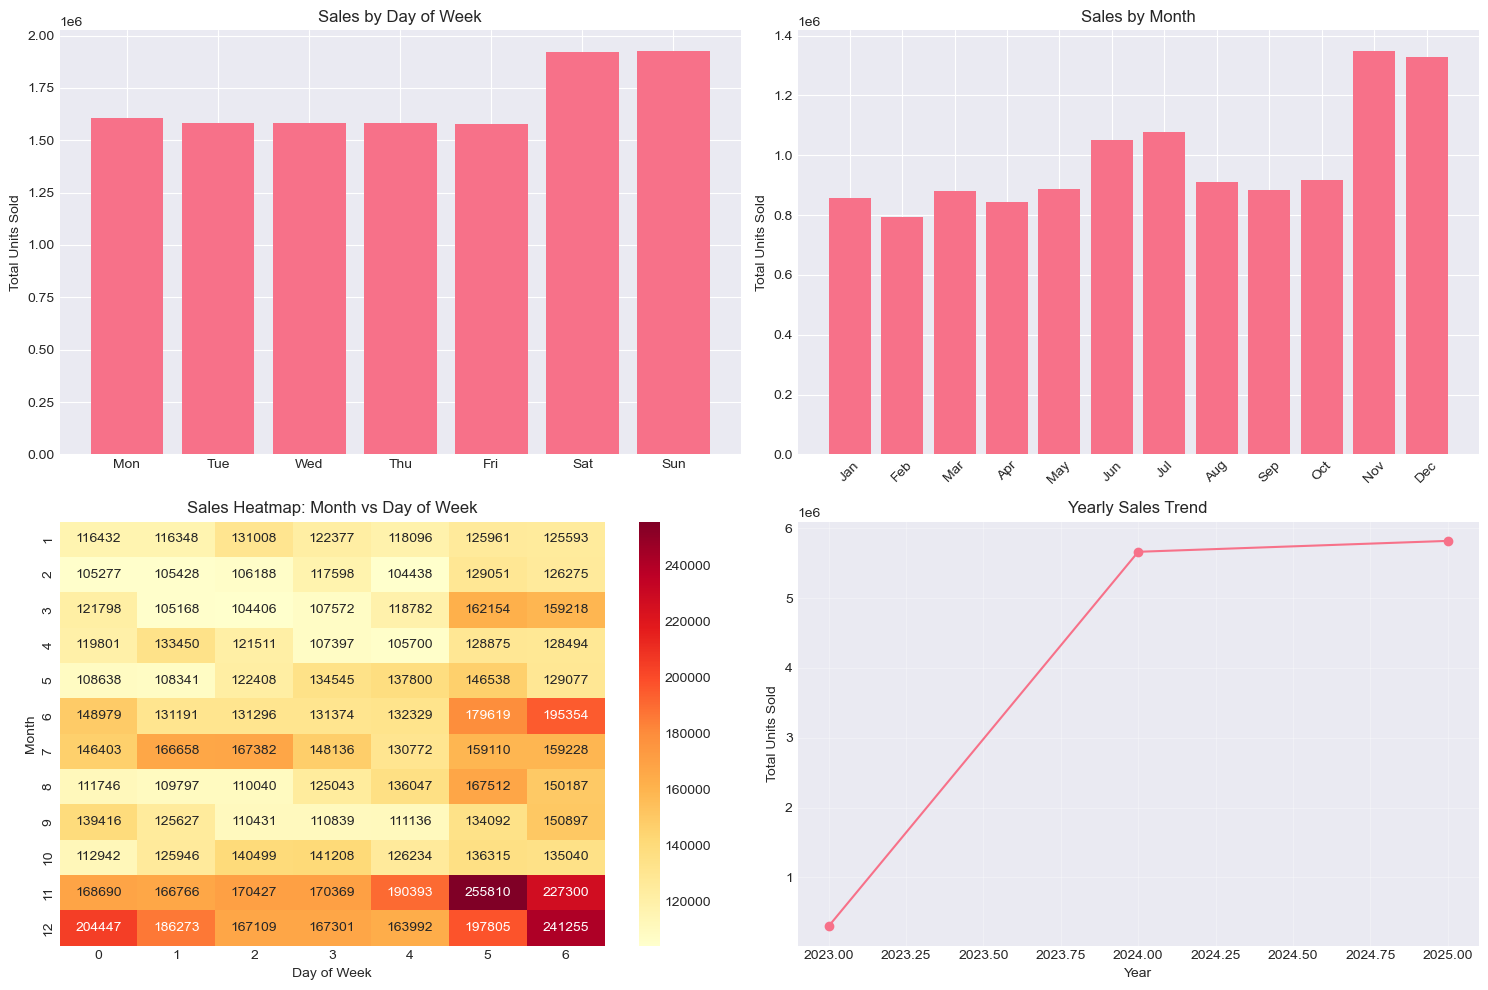

In [10]:
# Extract time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week

# Day of week analysis
dow_sales = df.groupby('day_of_week')['units_sold'].sum()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(range(7), dow_sales.values)
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(dow_labels)
axes[0, 0].set_ylabel('Total Units Sold')
axes[0, 0].set_title('Sales by Day of Week')

# Monthly analysis
monthly_sales = df.groupby('month')['units_sold'].sum()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[0, 1].bar(range(12), monthly_sales.values)
axes[0, 1].set_xticks(range(12))
axes[0, 1].set_xticklabels(month_labels, rotation=45)
axes[0, 1].set_ylabel('Total Units Sold')
axes[0, 1].set_title('Sales by Month')

# Heatmap: Day of week vs Month
if len(df) > 0:
    heatmap_data = df.groupby(['month', 'day_of_week'])['units_sold'].sum().unstack(fill_value=0)
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1, 0])
    axes[1, 0].set_title('Sales Heatmap: Month vs Day of Week')
    axes[1, 0].set_xlabel('Day of Week')
    axes[1, 0].set_ylabel('Month')

# Yearly trend
yearly_sales = df.groupby('year')['units_sold'].sum()
axes[1, 1].plot(yearly_sales.index, yearly_sales.values, marker='o')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Total Units Sold')
axes[1, 1].set_title('Yearly Sales Trend')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/visualizations/seasonality.png', dpi=300, bbox_inches='tight')
plt.show()


## Part 5: Trend Analysis

Identifying long-term trends and product life cycles.


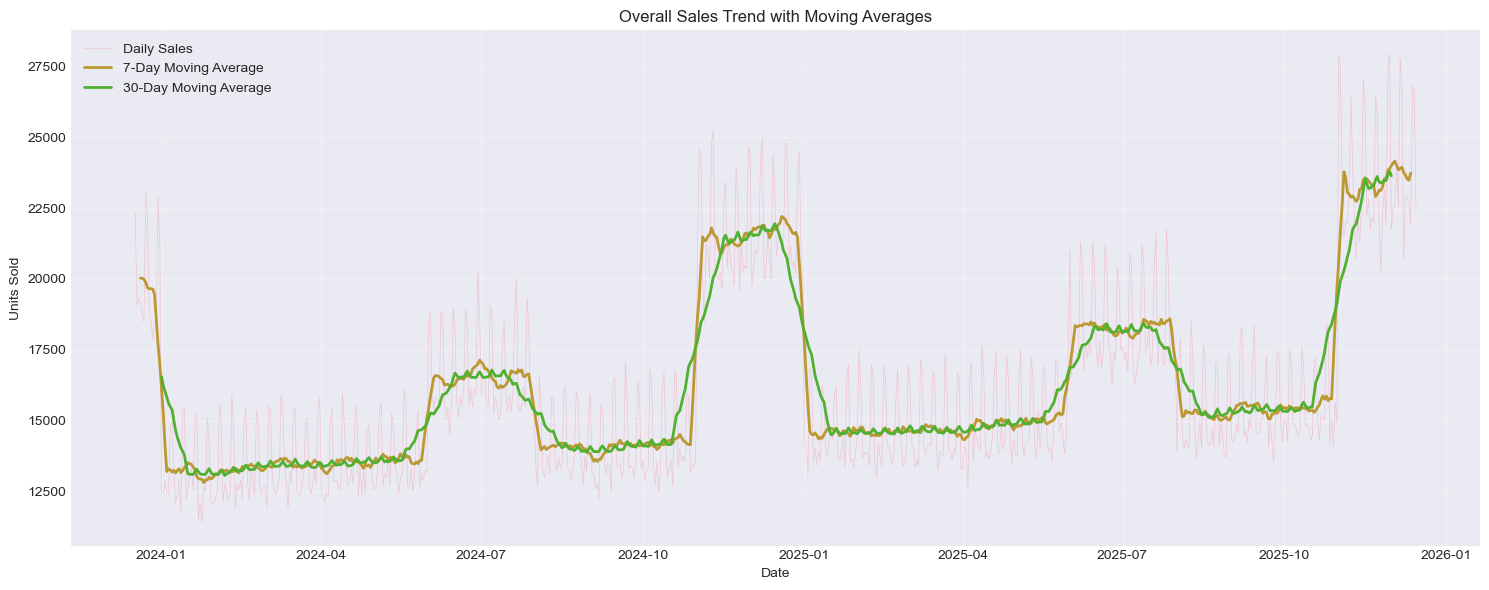

In [11]:
# Overall sales trend
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()
daily_sales['rolling_7'] = daily_sales['units_sold'].rolling(window=7, center=True).mean()
daily_sales['rolling_30'] = daily_sales['units_sold'].rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_sales['date'], daily_sales['units_sold'], alpha=0.3, label='Daily Sales', linewidth=0.5)
ax.plot(daily_sales['date'], daily_sales['rolling_7'], label='7-Day Moving Average', linewidth=2)
ax.plot(daily_sales['date'], daily_sales['rolling_30'], label='30-Day Moving Average', linewidth=2)
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.set_title('Overall Sales Trend with Moving Averages')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/visualizations/overall_trend.png', dpi=300, bbox_inches='tight')
plt.show()


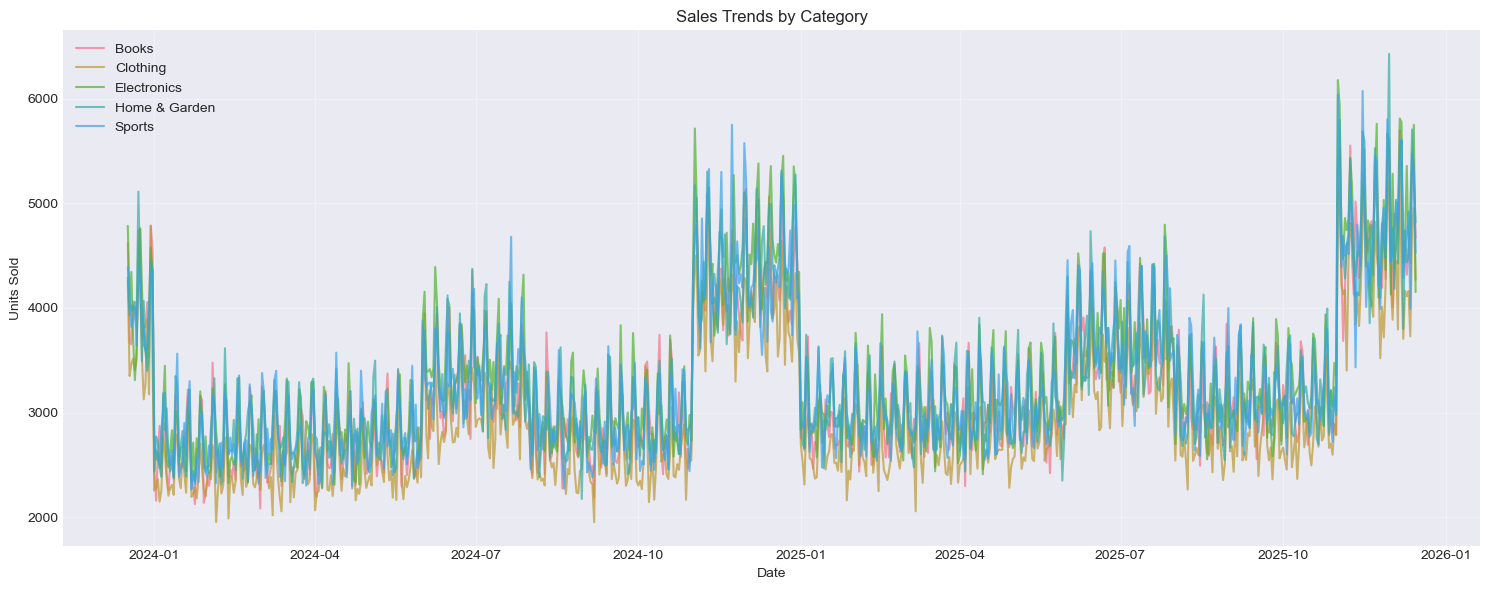

In [12]:
# Category trends
if 'category' in df.columns:
    category_trends = df.groupby(['date', 'category'])['units_sold'].sum().reset_index()
    category_trends = category_trends.pivot(index='date', columns='category', values='units_sold')
    
    fig, ax = plt.subplots(figsize=(15, 6))
    for category in category_trends.columns:
        ax.plot(category_trends.index, category_trends[category], 
               label=category, alpha=0.7, linewidth=1.5)
    ax.set_xlabel('Date')
    ax.set_ylabel('Units Sold')
    ax.set_title('Sales Trends by Category')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/category_trends.png', dpi=300, bbox_inches='tight')
    plt.show()


## Part 6: Product-Level Deep Dive

Understanding individual product patterns.


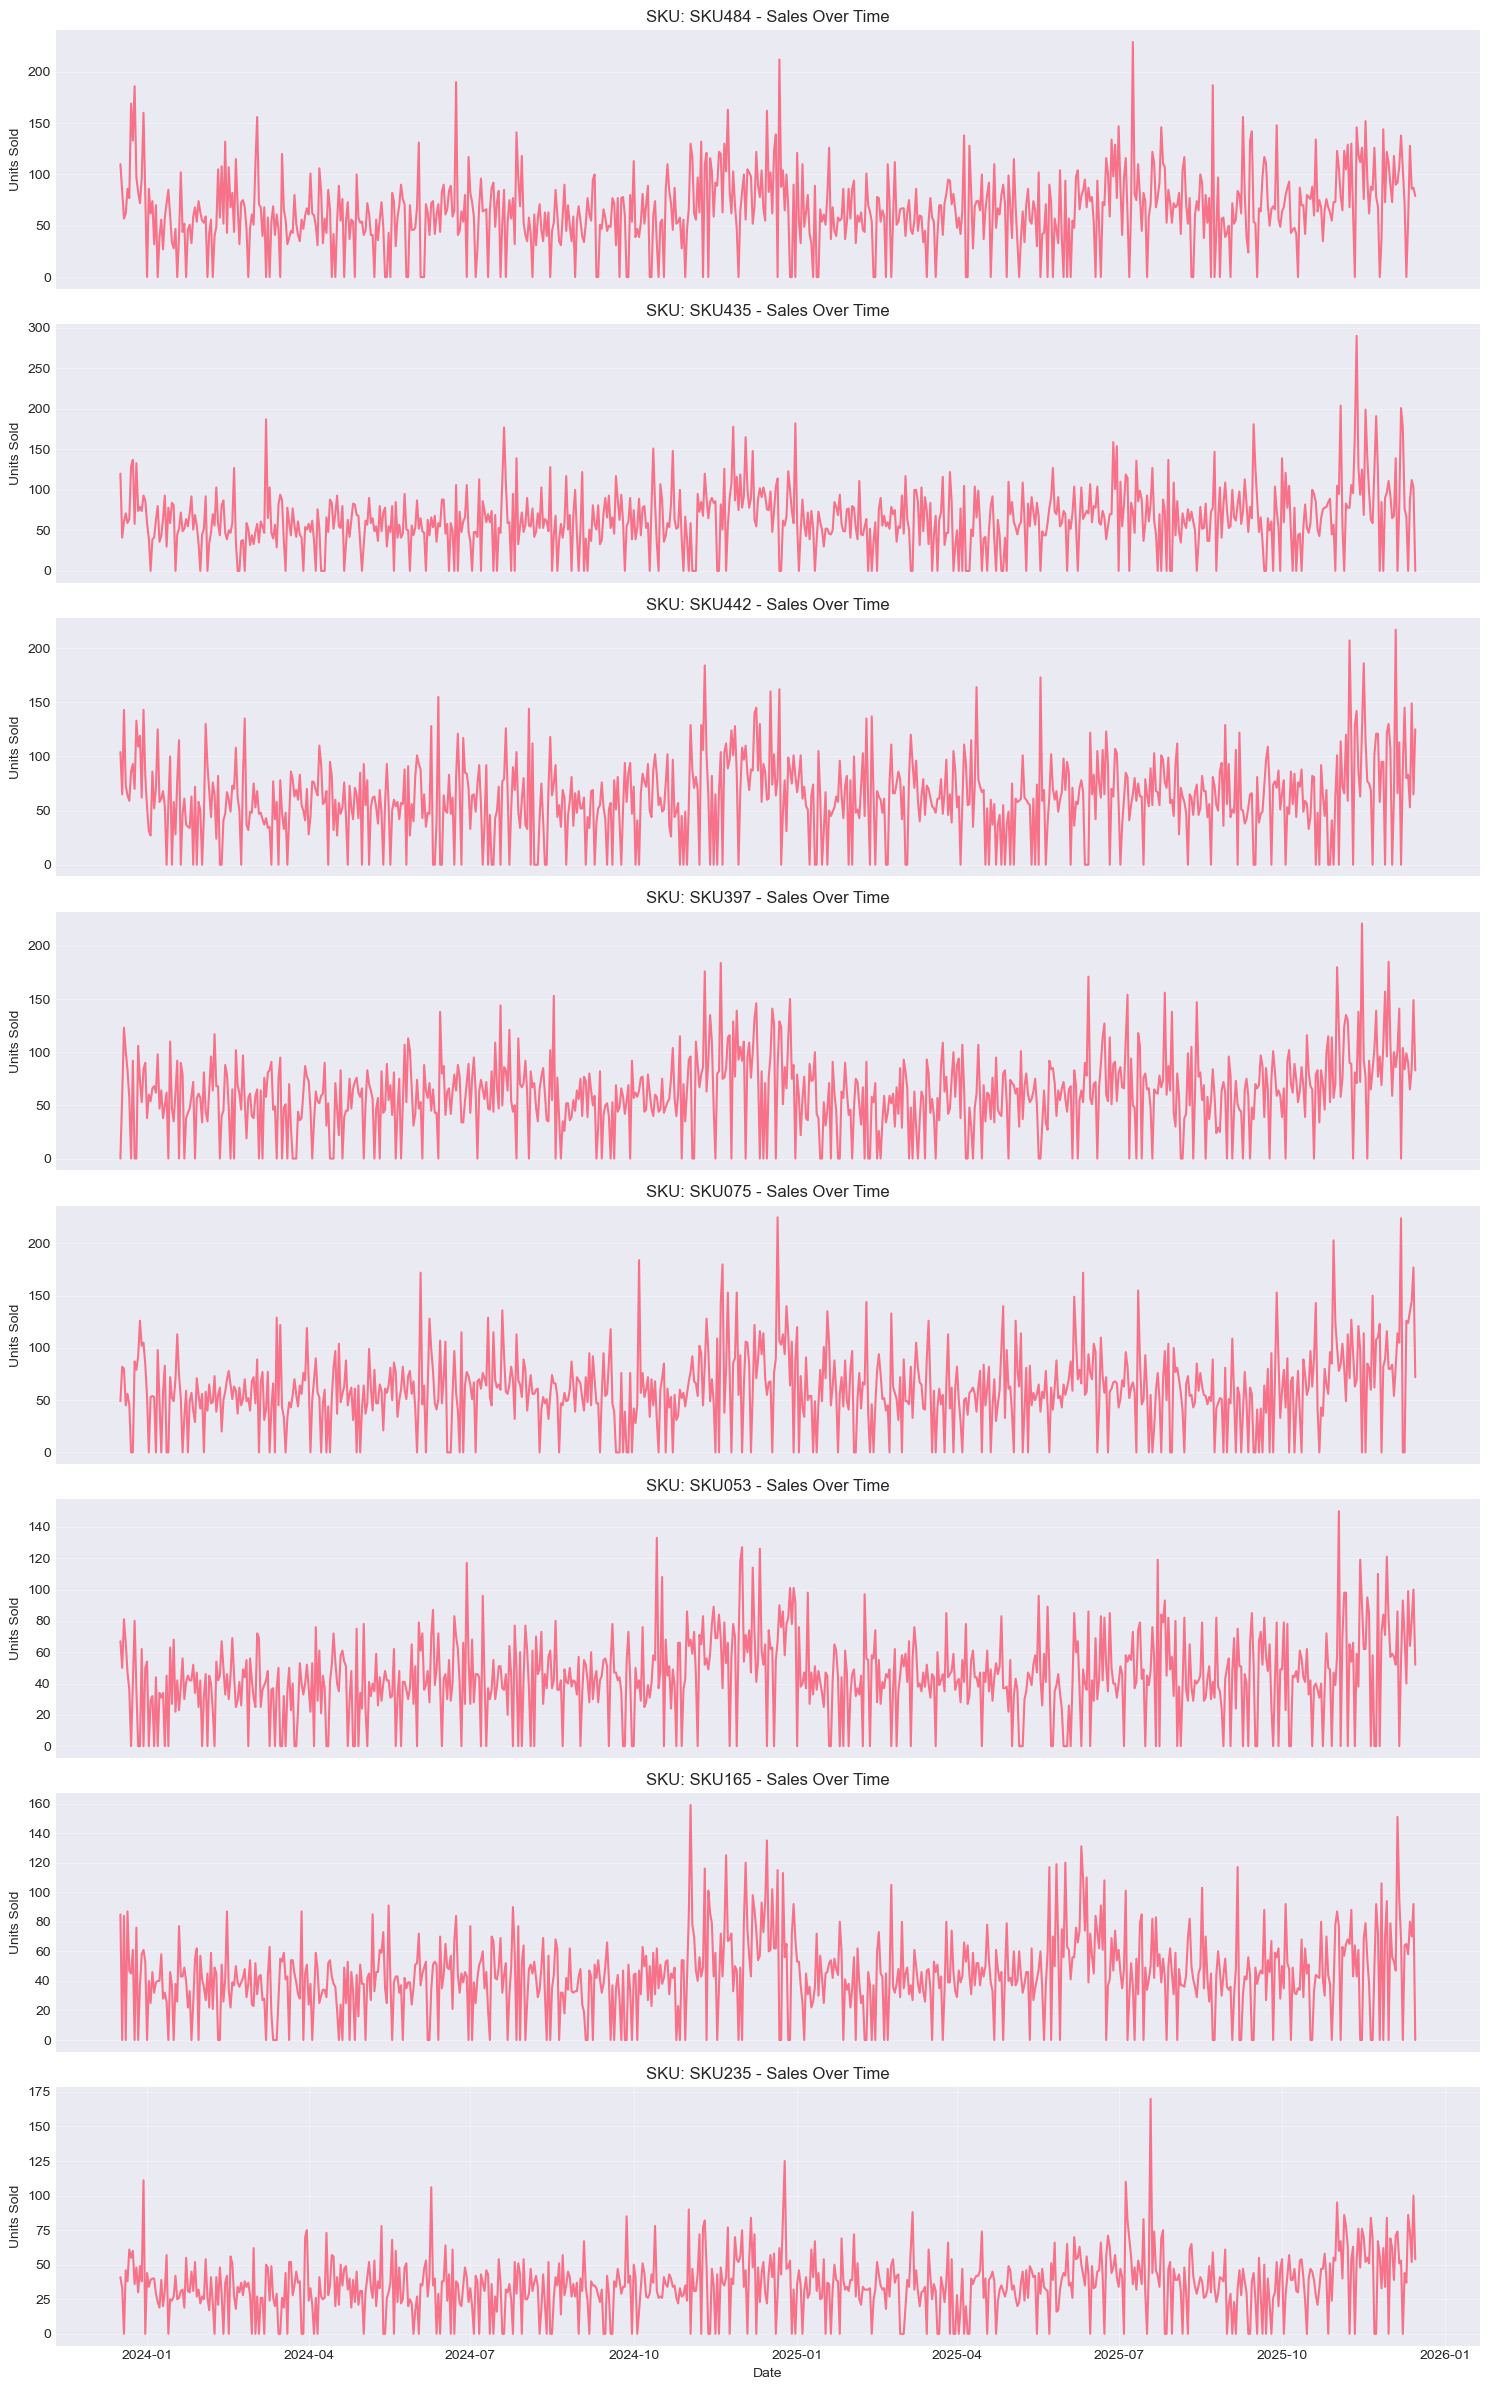

In [13]:
# Select representative SKUs for detailed analysis
top_skus = sku_performance.head(5).index.tolist()
random_skus = np.random.choice(df['sku_id'].unique(), 3, replace=False).tolist()
sample_skus = top_skus + list(random_skus)

fig, axes = plt.subplots(len(sample_skus), 1, figsize=(15, 3*len(sample_skus)))

for idx, sku in enumerate(sample_skus):
    sku_data = df[df['sku_id'] == sku].sort_values('date')
    axes[idx].plot(sku_data['date'], sku_data['units_sold'], linewidth=1.5)
    axes[idx].set_title(f'SKU: {sku} - Sales Over Time')
    axes[idx].set_ylabel('Units Sold')
    axes[idx].grid(True, alpha=0.3)
    if idx < len(sample_skus) - 1:
        axes[idx].set_xticks([])

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/visualizations/sku_time_series.png', dpi=300, bbox_inches='tight')
plt.show()


Demand Pattern Classification:
pattern
Regular    500
Name: count, dtype: int64


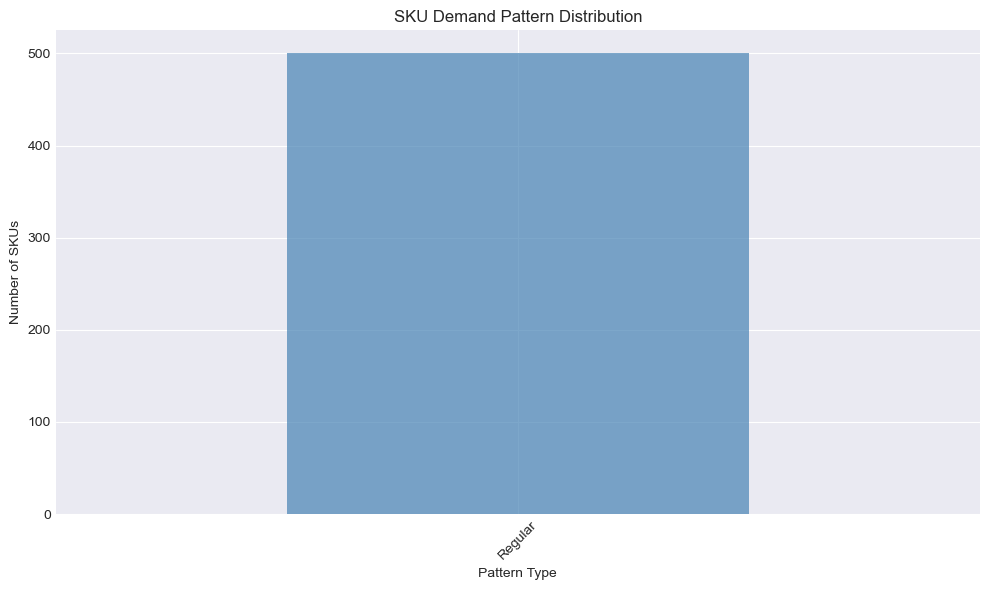

In [14]:
# Classify products by demand pattern
def classify_demand_pattern(sku_data):
    """Classify SKU demand pattern."""
    zero_ratio = (sku_data['units_sold'] == 0).sum() / len(sku_data)
    cv = sku_data['units_sold'].std() / (sku_data['units_sold'].mean() + 1e-6)
    
    if zero_ratio > 0.5:
        return 'Intermittent'
    elif cv > 1.5:
        return 'Erratic'
    elif cv < 0.5:
        return 'Smooth'
    else:
        return 'Regular'

sku_patterns = df.groupby('sku_id').apply(
    lambda x: classify_demand_pattern(x)
).reset_index(name='pattern')

pattern_counts = sku_patterns['pattern'].value_counts()
print("Demand Pattern Classification:")
print(pattern_counts)

plt.figure(figsize=(10, 6))
pattern_counts.plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('SKU Demand Pattern Distribution')
plt.xlabel('Pattern Type')
plt.ylabel('Number of SKUs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/visualizations/demand_patterns.png', dpi=300, bbox_inches='tight')
plt.show()


## Part 7: Promotion Analysis

Understanding promotion impact on sales.


Promotion vs Non-Promotion Sales:
               units_sold                        revenue
                     mean       sum   count         mean
promotion_flag                                          
False           30.722794  10092530  328503  3395.852206
True            46.194893   1685975   36497  4095.562469

Promotion Lift: 50.36%


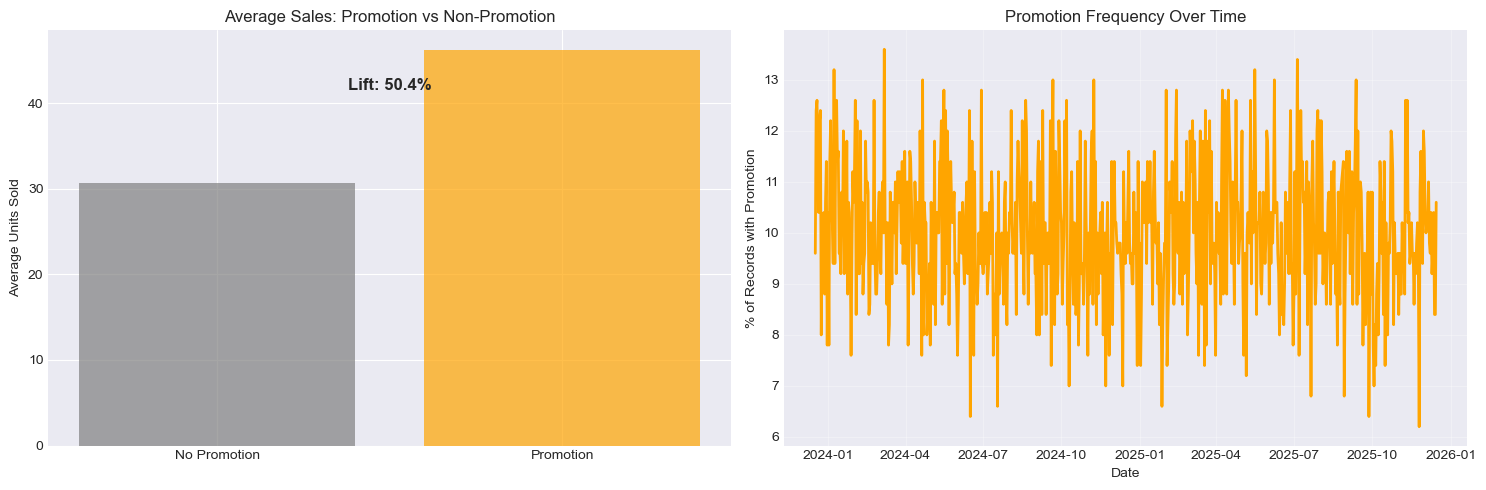

In [15]:
# Promotion analysis
if 'promotion_flag' in df.columns:
    promo_stats = df.groupby('promotion_flag').agg({
        'units_sold': ['mean', 'sum', 'count'],
        'revenue': 'mean'
    })
    
    print("Promotion vs Non-Promotion Sales:")
    print(promo_stats)
    
    # Calculate lift
    non_promo_avg = df[df['promotion_flag'] == False]['units_sold'].mean()
    promo_avg = df[df['promotion_flag'] == True]['units_sold'].mean()
    lift = ((promo_avg - non_promo_avg) / non_promo_avg) * 100
    
    print(f"\nPromotion Lift: {lift:.2f}%")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Sales comparison
    promo_comparison = df.groupby('promotion_flag')['units_sold'].mean()
    axes[0].bar(['No Promotion', 'Promotion'], promo_comparison.values, 
                color=['gray', 'orange'], alpha=0.7)
    axes[0].set_ylabel('Average Units Sold')
    axes[0].set_title('Average Sales: Promotion vs Non-Promotion')
    axes[0].text(0.5, promo_comparison.max() * 0.9, 
                f'Lift: {lift:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    # Promotion frequency over time
    promo_by_date = df.groupby('date')['promotion_flag'].mean() * 100
    axes[1].plot(promo_by_date.index, promo_by_date.values, linewidth=2, color='orange')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('% of Records with Promotion')
    axes[1].set_title('Promotion Frequency Over Time')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/promotion_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Promotion data not available in dataset")


## Part 8: Data Quality Assessment

Identifying data issues that need to be addressed.


In [16]:
# Data validation
validation_results = validate_data(df)

print("Data Validation Results:")
print("="*50)
print(f"Valid: {validation_results['is_valid']}")
print(f"Shape: {validation_results['shape']}")
print(f"Date Range: {validation_results['date_range']}")

if validation_results['issues']:
    print("\nIssues Found:")
    for issue in validation_results['issues']:
        print(f"  - {issue}")
    
    print("\nRecommendations:")
    for rec in validation_results['recommendations']:
        print(f"  - {rec}")
else:
    print("\n✓ No major data quality issues detected!")


Data Validation Results:
Valid: True
Shape: (365000, 14)
Date Range: (Timestamp('2023-12-17 00:00:00'), Timestamp('2025-12-15 00:00:00'))

✓ No major data quality issues detected!


Outliers detected: 7951 (2.18%)

Sample outliers:
          date  sku_id  units_sold   price
3   2023-12-17  SKU004         120  130.11
13  2023-12-17  SKU014         116  189.12
16  2023-12-17  SKU017         186  122.48
21  2023-12-17  SKU022         105  182.81
61  2023-12-17  SKU062         130   85.24
64  2023-12-17  SKU065         109  102.43
85  2023-12-17  SKU086         102   54.28
105 2023-12-17  SKU106         156  111.06
129 2023-12-17  SKU130         100   47.35
134 2023-12-17  SKU135         124   68.96


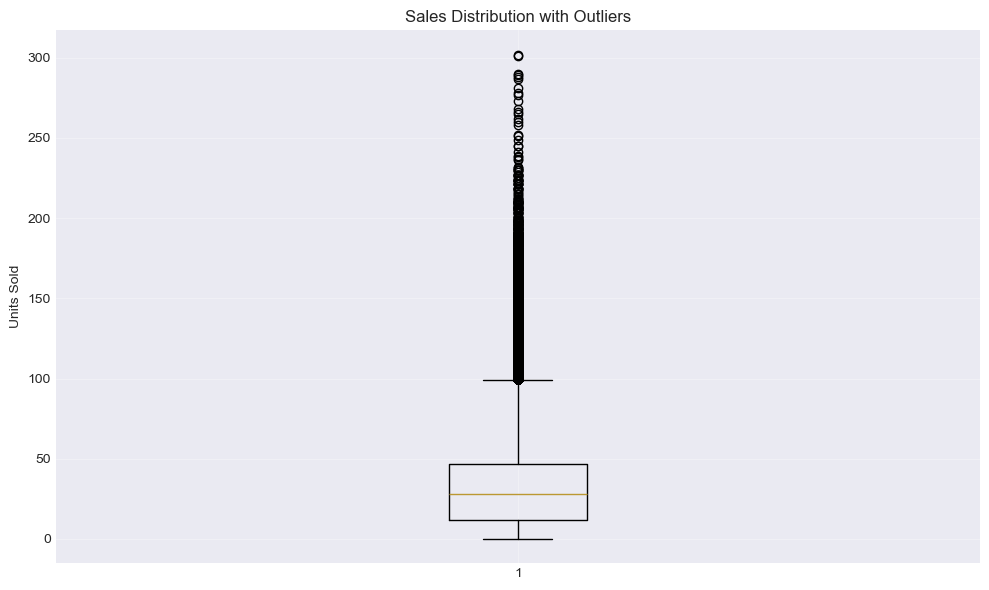

In [17]:
# Outlier detection
Q1 = df['units_sold'].quantile(0.25)
Q3 = df['units_sold'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['units_sold'] < lower_bound) | (df['units_sold'] > upper_bound)]
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print("\nSample outliers:")
    print(outliers[['date', 'sku_id', 'units_sold', 'price']].head(10))
    
    # Visualize outliers
    plt.figure(figsize=(10, 6))
    plt.boxplot(df['units_sold'], vert=True)
    plt.ylabel('Units Sold')
    plt.title('Sales Distribution with Outliers')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/outliers.png', dpi=300, bbox_inches='tight')
    plt.show()


## Summary and Key Insights

Let's document the key findings from our exploration.


In [18]:
# Generate summary report
summary = {
    'Data Overview': {
        'Total Records': len(df),
        'Date Range': f"{df['date'].min()} to {df['date'].max()}",
        'Unique SKUs': df['sku_id'].nunique(),
        'Unique Categories': df['category'].nunique() if 'category' in df.columns else 'N/A'
    },
    'Sales Statistics': {
        'Total Units Sold': int(df['units_sold'].sum()),
        'Total Revenue': f"${df['revenue'].sum():,.2f}" if 'revenue' in df.columns else 'N/A',
        'Average Daily Sales': f"{df['units_sold'].mean():.2f}",
        'Median Daily Sales': f"{df['units_sold'].median():.2f}",
        'Zero Sales Days': f"{(df['units_sold'] == 0).sum()} ({(df['units_sold'] == 0).sum()/len(df)*100:.2f}%)"
    },
    'Time Patterns': {
        'Peak Day of Week': dow_labels[dow_sales.idxmax()],
        'Peak Month': month_labels[monthly_sales.idxmax() - 1],
        'Yearly Trend': 'Increasing' if len(yearly_sales) > 1 and yearly_sales.iloc[-1] > yearly_sales.iloc[0] else 'Stable/Decreasing'
    }
}

if 'promotion_flag' in df.columns:
    summary['Promotions'] = {
        'Promotion Frequency': f"{(df['promotion_flag'] == True).sum() / len(df) * 100:.2f}%",
        'Average Lift': f"{lift:.2f}%"
    }

print("="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)
for section, items in summary.items():
    print(f"\n{section}:")
    print("-" * 40)
    for key, value in items.items():
        print(f"  {key}: {value}")

# Save summary to file
import json
with open('../outputs/reports/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("\n" + "="*60)
print("✓ Summary saved to outputs/reports/eda_summary.json")
print("✓ Visualizations saved to outputs/visualizations/")
print("="*60)


EXPLORATORY DATA ANALYSIS SUMMARY

Data Overview:
----------------------------------------
  Total Records: 365000
  Date Range: 2023-12-17 00:00:00 to 2025-12-15 00:00:00
  Unique SKUs: 500
  Unique Categories: 5

Sales Statistics:
----------------------------------------
  Total Units Sold: 11778505
  Total Revenue: $1,265,023,380.72
  Average Daily Sales: 32.27
  Median Daily Sales: 28.00
  Zero Sales Days: 54802 (15.01%)

Time Patterns:
----------------------------------------
  Peak Day of Week: Sun
  Peak Month: Nov
  Yearly Trend: Increasing

Promotions:
----------------------------------------
  Promotion Frequency: 10.00%
  Average Lift: 50.36%

✓ Summary saved to outputs/reports/eda_summary.json
✓ Visualizations saved to outputs/visualizations/
